# Main vs Chance Baseline

Evaluates three uninformed strategies against GC-CNN.
No training required — run after main pipeline produces lopo_results.csv.

In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, CANONICAL_CHANNELS, N_CHANNELS, FS,
    WINDOW_SEC, STEP_SEC, PREICTAL_SEC, SPH_SEC,
    POSTICTAL_EXCL_SEC, EXCLUDED_PATIENTS, RANDOM_SEED, RESULTS_DIR
)
from summary_parser import parse_all_summaries
from data_loader    import load_edf
from preprocessing  import bandpass_filter, segment_signal, label_windows
from metrics        import evaluate_predictions
np.random.seed(RANDOM_SEED)
print('Setup complete.')

Setup complete.


In [2]:
# Cell 1 — Parse & build label arrays
all_seizures = parse_all_summaries(DATA_ROOT)
print(f'Parsed {len(all_seizures)} patient entries.')
label_data = {}
patients = sorted([p for p in os.listdir(DATA_ROOT)
                   if os.path.isdir(os.path.join(DATA_ROOT, p))
                   and p.startswith('chb')
                   and p not in EXCLUDED_PATIENTS])

for patient_id in patients:
    file_seizure_map = all_seizures.get(patient_id, {})
    if not file_seizure_map:
        continue

    all_y = []
    for filename in sorted(file_seizure_map):
        seizures = file_seizure_map[filename]
        if not seizures:
            continue
        edf_path = os.path.join(DATA_ROOT, patient_id, filename)
        if not os.path.exists(edf_path):
            continue
        try:
            signal, fs = load_edf(edf_path)
        except Exception as e:
            continue
        filtered  = bandpass_filter(signal)
        n_samples = filtered.shape[1]
        labels    = label_windows(n_samples, seizures)
        labels    = labels[labels != -1]
        if (labels == 1).sum() == 0:
            continue
        all_y.append(labels)

    if not all_y:
        continue
    y = np.concatenate(all_y)
    label_data[patient_id] = y
    print(f'[INFO] {patient_id}: {len(y)} windows  '
          f'preictal={(y==1).sum()}  interictal={(y==0).sum()}')

patient_ids = sorted(label_data.keys())
print(f'\nLabel data ready for {len(label_data)} patients.')

[INFO] chb01: 7 seizure-containing files, 7 total seizures
[INFO] chb02: 3 seizure-containing files, 3 total seizures
[INFO] chb03: 7 seizure-containing files, 7 total seizures
[INFO] chb04: 3 seizure-containing files, 4 total seizures
[INFO] chb05: 5 seizure-containing files, 5 total seizures
[INFO] chb06: 7 seizure-containing files, 10 total seizures
[INFO] chb07: 3 seizure-containing files, 3 total seizures
[INFO] chb08: 5 seizure-containing files, 5 total seizures
[INFO] chb09: 3 seizure-containing files, 4 total seizures
[INFO] chb10: 7 seizure-containing files, 7 total seizures
[INFO] chb11: 3 seizure-containing files, 3 total seizures
[INFO] chb12: 13 seizure-containing files, 40 total seizures
[INFO] chb13: 8 seizure-containing files, 12 total seizures
[INFO] chb14: 7 seizure-containing files, 8 total seizures
[INFO] chb15: 14 seizure-containing files, 20 total seizures
[INFO] chb16: 6 seizure-containing files, 10 total seizures
[INFO] chb17: 3 seizure-containing files, 3 total

In [3]:
# Cell 2 — Evaluate chance strategies
strategies = ['random_uniform', 'majority_class', 'stratified_random']
chance_results = {s: {} for s in strategies}

for test_pid in patient_ids:
    y_test = label_data[test_pid]
    n      = len(y_test)
    prev   = (y_test == 1).mean()

    scores_rand  = np.random.uniform(0, 1, size=n)
    scores_maj   = np.zeros(n, dtype=np.float32)
    scores_strat = np.random.binomial(1, prev, size=n).astype(np.float32)

    for strat, scores in zip(strategies, [scores_rand, scores_maj, scores_strat]):
        chance_results[strat][test_pid] = evaluate_predictions(
            y_test, scores, threshold=0.5, patient_id=test_pid
        )

print('Chance evaluation complete.')

Chance evaluation complete.


In [4]:
# Cell 3 — Summary & save
METRIC_KEYS = ['auc', 'auc_pr', 'sensitivity', 'specificity', 'f1', 'balanced_accuracy', 'fpr_per_hour']

os.makedirs(RESULTS_DIR, exist_ok=True)
for strategy in strategies:
    rows = [{'patient': pid, **{k: chance_results[strategy][pid][k] for k in METRIC_KEYS}}
            for pid in patient_ids]
    df = pd.DataFrame(rows)
    df = pd.concat([df,
        pd.DataFrame([{'patient': 'MEAN', **{k: round(df[k].mean(),4) for k in METRIC_KEYS}}]),
        pd.DataFrame([{'patient': 'STD',  **{k: round(df[k].std(), 4) for k in METRIC_KEYS}}])
    ], ignore_index=True)
    print(f'\n=== {strategy} ===')
    print(df.to_string(index=False, float_format='{:.3f}'.format))
    df.to_csv(os.path.join(RESULTS_DIR, f'lopo_chance_{strategy}.csv'), index=False)
print('\nAll saved.')


=== random_uniform ===
patient   auc  auc_pr  sensitivity  specificity    f1  balanced_accuracy  fpr_per_hour
  chb01 0.520   0.648        0.524        0.503 0.574              0.513       178.994
  chb02 0.502   0.487        0.527        0.495 0.506              0.511       181.651
  chb03 0.514   0.699        0.500        0.537 0.580              0.519       166.542
  chb04 0.478   0.143        0.466        0.515 0.217              0.490       174.666
  chb05 0.492   0.647        0.466        0.514 0.536              0.490       174.980
  chb06 0.498   0.165        0.500        0.504 0.244              0.502       178.673
  chb07 0.477   0.151        0.490        0.479 0.223              0.485       187.379
  chb08 0.486   0.568        0.468        0.505 0.513              0.486       178.318
  chb09 0.494   0.206        0.483        0.492 0.284              0.488       182.824
  chb10 0.470   0.243        0.469        0.486 0.320              0.477       184.980
  chb11 0.460   0.5

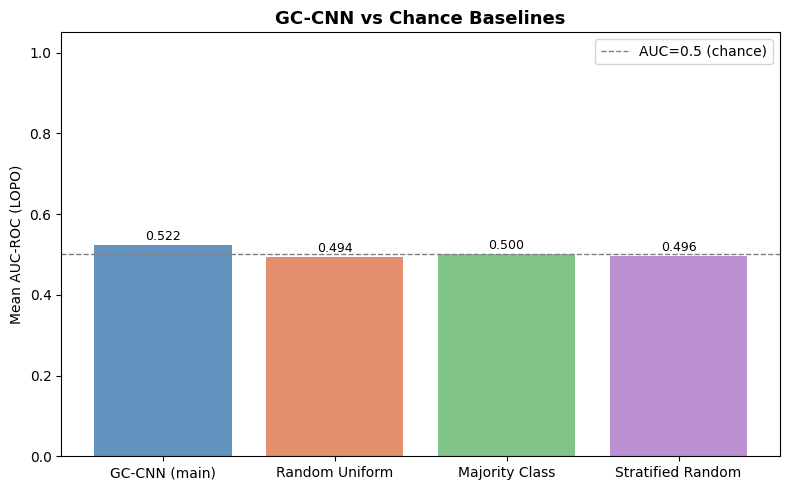

Plot saved.


In [5]:
# Cell 4 — Comparison plot vs GC-CNN
gc_csv = os.path.join(RESULTS_DIR, 'lopo_results.csv')
if not os.path.exists(gc_csv):
    print('Run main pipeline first.')
else:
    gc_df = pd.read_csv(gc_csv)
    pid_col = [c for c in gc_df.columns if 'patient' in c.lower()][0]
    gc_df   = gc_df.rename(columns={pid_col: 'patient'})
    gc_df   = gc_df[~gc_df['patient'].isin(['MEAN','STD'])].reset_index(drop=True)

    labels_map = {'random_uniform': 'Random Uniform',
                  'majority_class': 'Majority Class',
                  'stratified_random': 'Stratified Random'}
    palette = ['#e07b54', '#6bba75', '#b07ec9']

    summary = {}
    # GC-CNN main uses 'auc' column
    auc_col = 'auc' if 'auc' in gc_df.columns else gc_df.columns[1]
    summary['GC-CNN (main)'] = gc_df[auc_col].mean()
    colors = {'GC-CNN (main)': 'steelblue'}

    for s, col in zip(strategies, palette):
        vals = [chance_results[s][p]['auc'] for p in patient_ids]
        summary[labels_map[s]] = np.mean(vals)
        colors[labels_map[s]]  = col

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(list(summary.keys()), list(summary.values()),
                  color=list(colors.values()), alpha=0.85)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='AUC=0.5 (chance)')
    for bar, val in zip(bars, summary.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Mean AUC-ROC (LOPO)')
    ax.set_title('GC-CNN vs Chance Baselines', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'comparison_gc_vs_chance.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved.')